# Sudan EDA

Task 2 implementation for Sudan with full profiling, cleaning, export, and visual diagnostics.

Duplicates found/dropped: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,6.423564,2020.131451
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,3.477046,3.248907
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,1.000000,2015.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,3.000000,2017.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,6.000000,2020.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,9.000000,2023.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,12.000000,2026.000000


,null_count,null_pct


Columns with >5% nulls: []
Outlier rows flagged (|Z| > 3): 84
{'country': 'sudan', 'duplicates_dropped': 0, 'outlier_rows_flagged': 84, 'missing_pct': {'YEAR': 0.0, 'DOY': 0.0, 'T2M': 0.0, 'T2M_MAX': 0.0, 'T2M_MIN': 0.0, 'T2M_RANGE': 0.0, 'PRECTOTCORR': 0.0, 'RH2M': 0.0, 'WS2M': 0.0, 'WS2M_MAX': 0.0, 'PS': 0.0, 'QV2M': 0.0, 'Country': 0.0, 'DATE': 0.0, 'Month': 0.0, 'Year': 0.0, 'is_outlier': 0.0}, 'cols_over_5pct_null': [], 'rows_after_imputation': 4108, 'exported_to': 'data/sudan_clean.csv'}


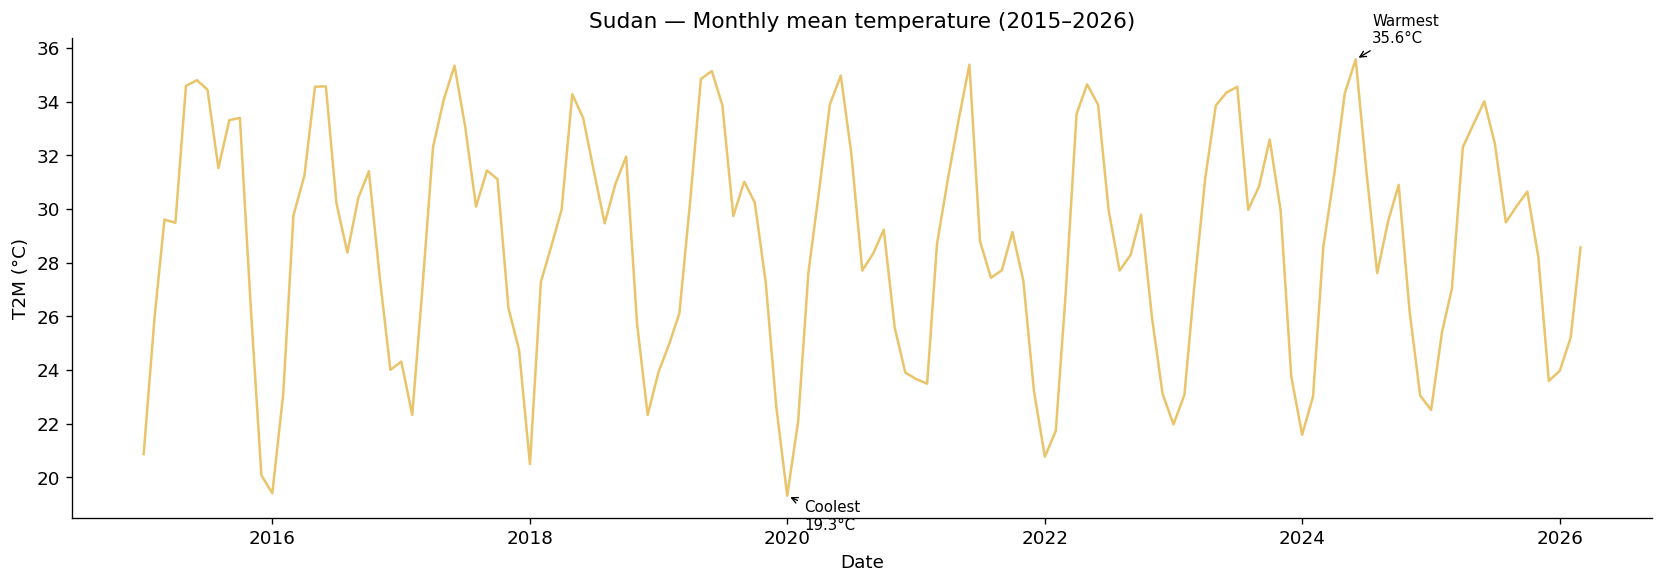

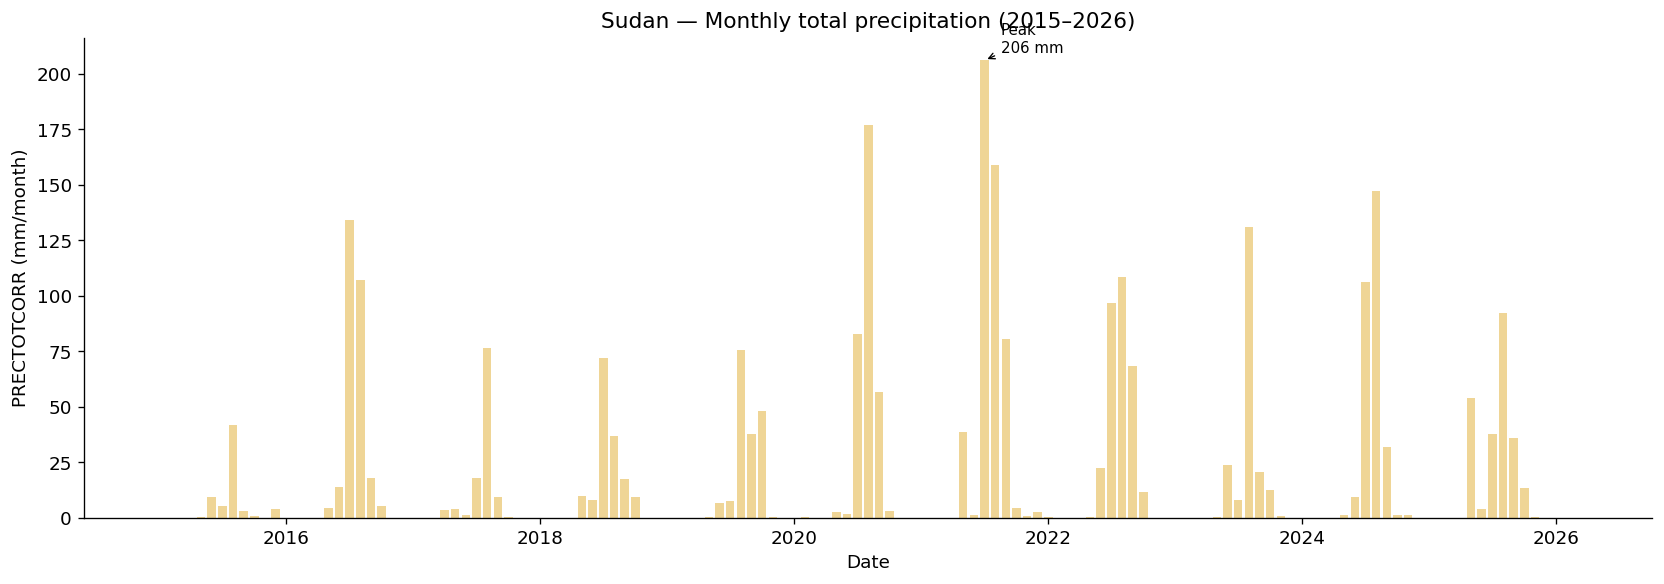

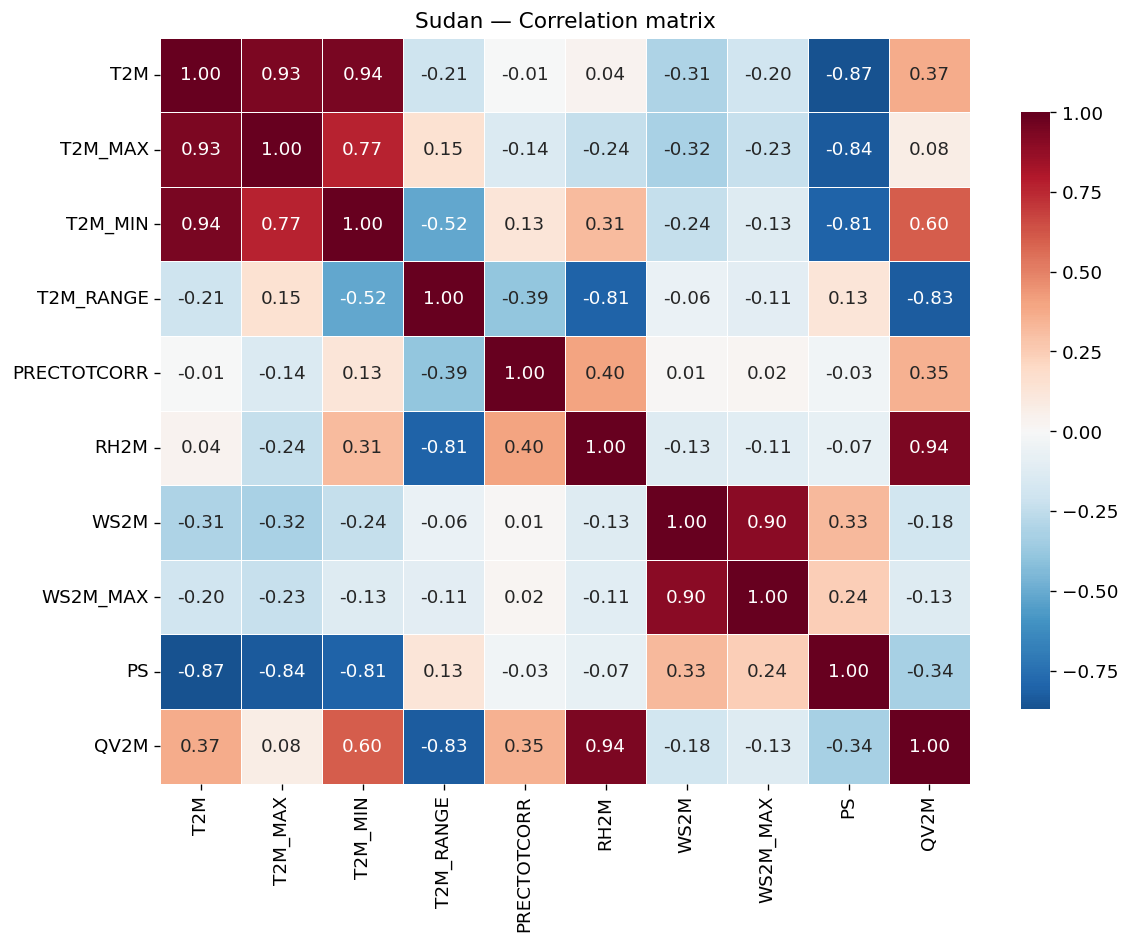

In [1]:
from pathlib import Path
import numpy as np
from src.data_loader import load_country
from src.cleaning import drop_duplicates, flag_outliers, run_cleaning_pipeline
from src.eda_utils import missing_value_report
from src.visualization import monthly_temperature, monthly_precipitation, correlation_heatmap

COUNTRY = "sudan"
df = load_country(COUNTRY, data_dir=Path("data"))
df, dup_count = drop_duplicates(df)
print(f"Duplicates found/dropped: {dup_count}")
display(df.describe(include=[np.number]))
na_report = missing_value_report(df)
display(na_report)
print("Columns with >5% nulls:", na_report[na_report['null_pct'] > 5].index.tolist())
flagged = flag_outliers(df)
print("Outlier rows flagged (|Z| > 3):", int(flagged['is_outlier'].sum()))
clean_df, report = run_cleaning_pipeline(df, COUNTRY, data_dir=Path("data"))
print(report)
monthly_temperature(clean_df, country=COUNTRY.capitalize())
monthly_precipitation(clean_df, country=COUNTRY.capitalize())
correlation_heatmap(clean_df, country=COUNTRY.capitalize())
